### 0. Выполнить импорты библиотек и настроку показа в ноутбуке

In [1]:
import pandas as pd
import load_data as ld
import seaborn as sns
import graph as gr

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

import numpy as np
import warnings

from scipy.integrate import odeint
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", "is_categorical_dtype")
plt.style.use('ggplot')

### Архив


# 1 Общий анализ данных

### 1.1 Нарисовать возрастно-половые пирамиды для фактических расперделений

2024-04-23 21:08:23.466567 : Выполняется отрисовка возрастных пирамид для фактических данных ... 


<Figure size 2000x1000 with 0 Axes>

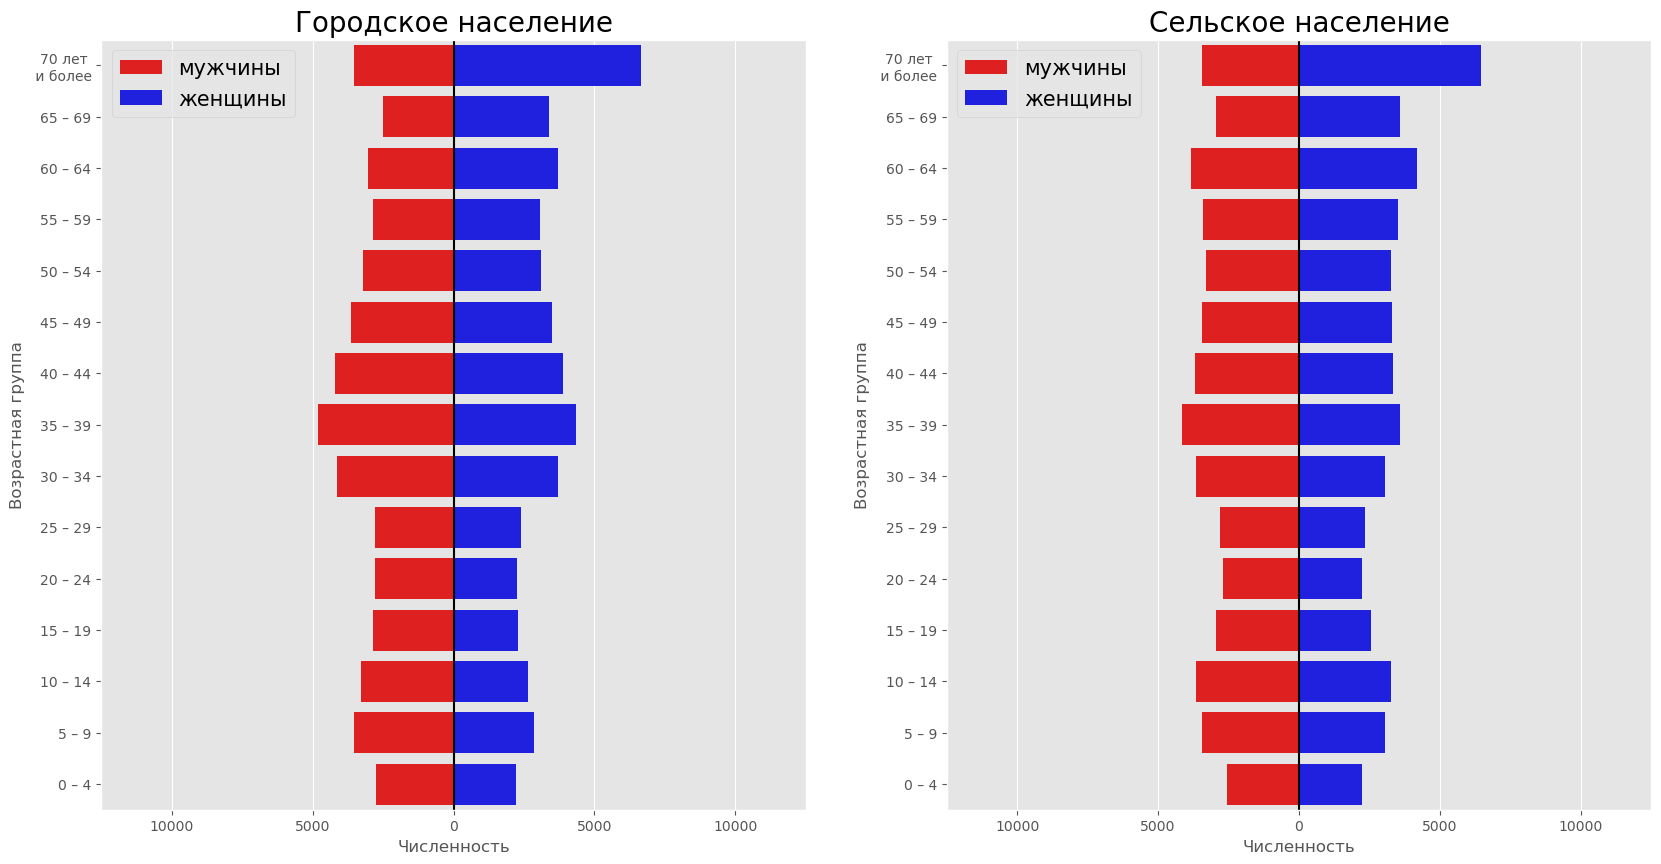

In [2]:
# размер популяции для которого нарисовать пирамиду
population_size = 200000 

model = gr.MyPopulation()
model.plot_age_sex_distribution(population_size=population_size,
                                max_xlimit=population_size/16,
                                age_sex_distribution_filename="input/age_sex_distribution_percentage.xlsx",
                                save_path="D:/Учёба/4_курс/Диплом/текст/img/tree_theory.png");


### 1.2 Сгенерировать популяцию по заданным шаблонам

In [3]:
population_size = 30000
model = gr.MyPopulation()
model.generate_total_population(population_size = population_size, 
                                largest_manufactures_number=13,
                                lockdown=False)

2024-04-23 21:08:25.313750 : Строится популяция для городского населения ... 
2024-04-23 21:08:25.313750 : Запуск функции создания популяции ... 
2024-04-23 21:08:25.730566 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:08:25.746197 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:08:25.768344 : Формирование домохозяйств ... 
2024-04-23 21:08:25.853014 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:08:27.134234 : Создается контакты внутри школ ... 
2024-04-23 21:08:27.535423 : Создается контакты внутри предприятий ... 
Значение параметра largest_manufactures_number было изменено на: 12
Значение параметра largest_manufactures_number было изменено на: 11
Значение параметра largest_manufactures_number было изменено на: 10


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:08:28.623058 : Создается контакты внутри университетов ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:08:29.525471 : Создание популяции завершено ... 
2024-04-23 21:08:29.563253 : Строится популяция для сельского населения ... 
2024-04-23 21:08:29.563253 : Запуск функции создания популяции ... 
2024-04-23 21:08:29.879774 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:08:29.895405 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:08:29.926665 : Формирование домохозяйств ... 
2024-04-23 21:08:29.980071 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:08:31.373100 : Создается контакты внутри школ ... 
2024-04-23 21:08:31.900743 : Создается контакты внутри предприятий ... 
Значение параметра largest_manufactures_number было изменено на: 12
Значение параметра largest_manufactures_number было изменено на: 11
Значение параметра largest_manufactures_number было изменено на: 10


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:08:32.987688 : Создается контакты внутри университетов ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:08:33.783558 : Создание популяции завершено ... 


0

### 1.3 Нарисовать возрастно-половые пирамиды для сгенерированной популяции

Создать полную популяцию для городского и сельского населения

2024-04-23 21:09:07.590722 : Выполняется отрисовка возрастных пирамид для сгенерированной популяции ... 


<Figure size 2000x1000 with 0 Axes>

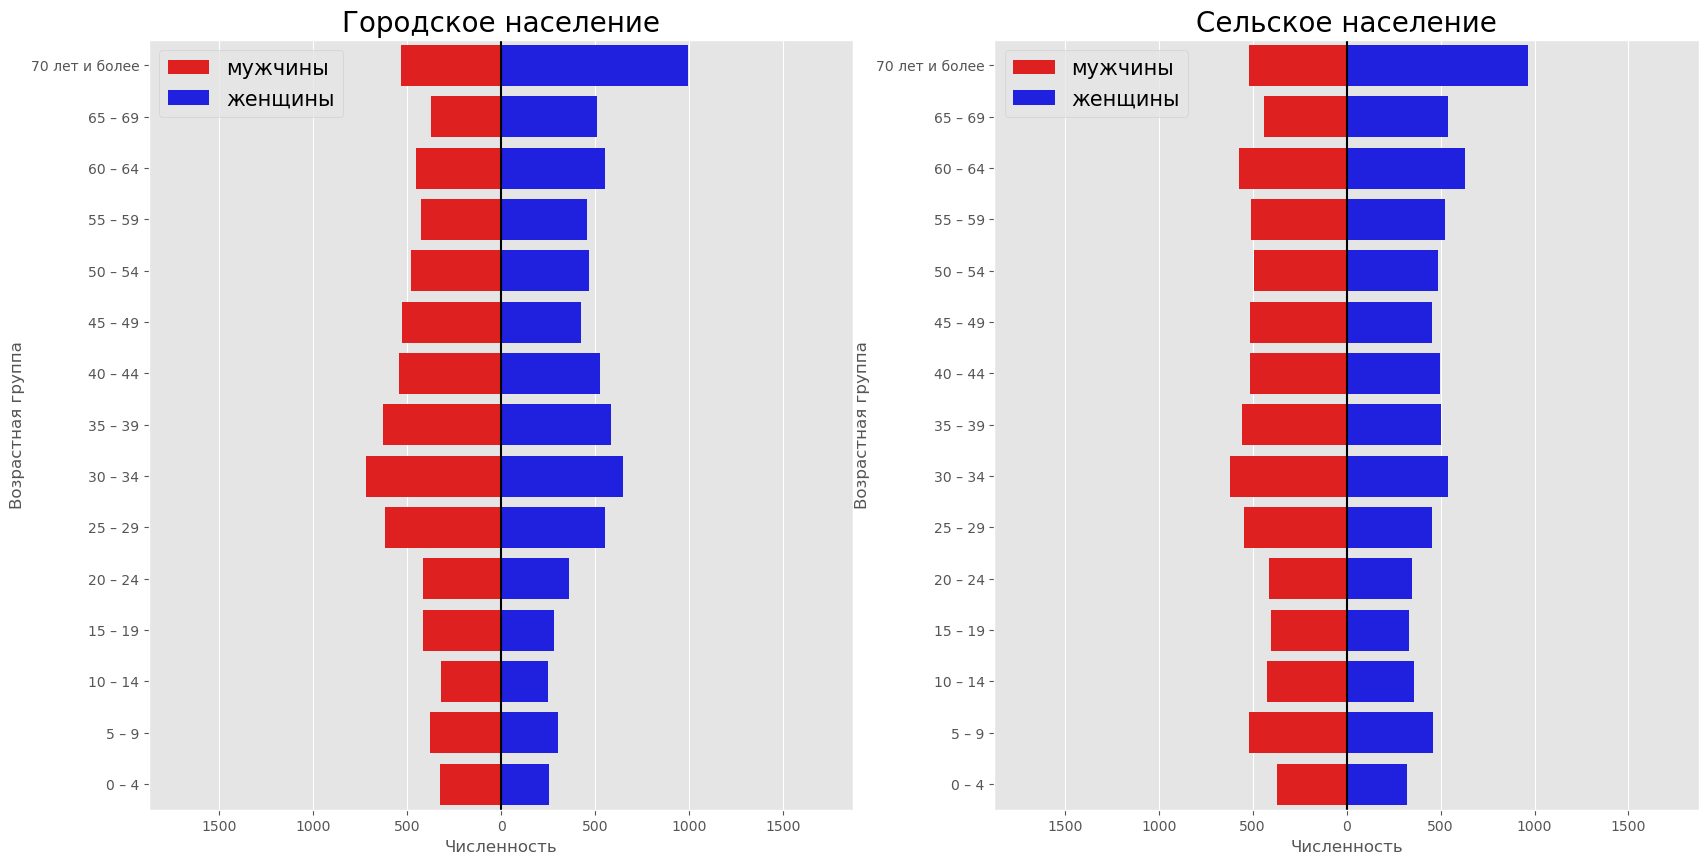

In [5]:
model.plot_age_sex_distribution(max_xlimit=population_size/16,
                                population_size=population_size,
                                use_generated_population=True);

### 1.4 Посмотреть распределения внутри домохозяйств для фактических данных

0

<Figure size 2000x1000 with 0 Axes>

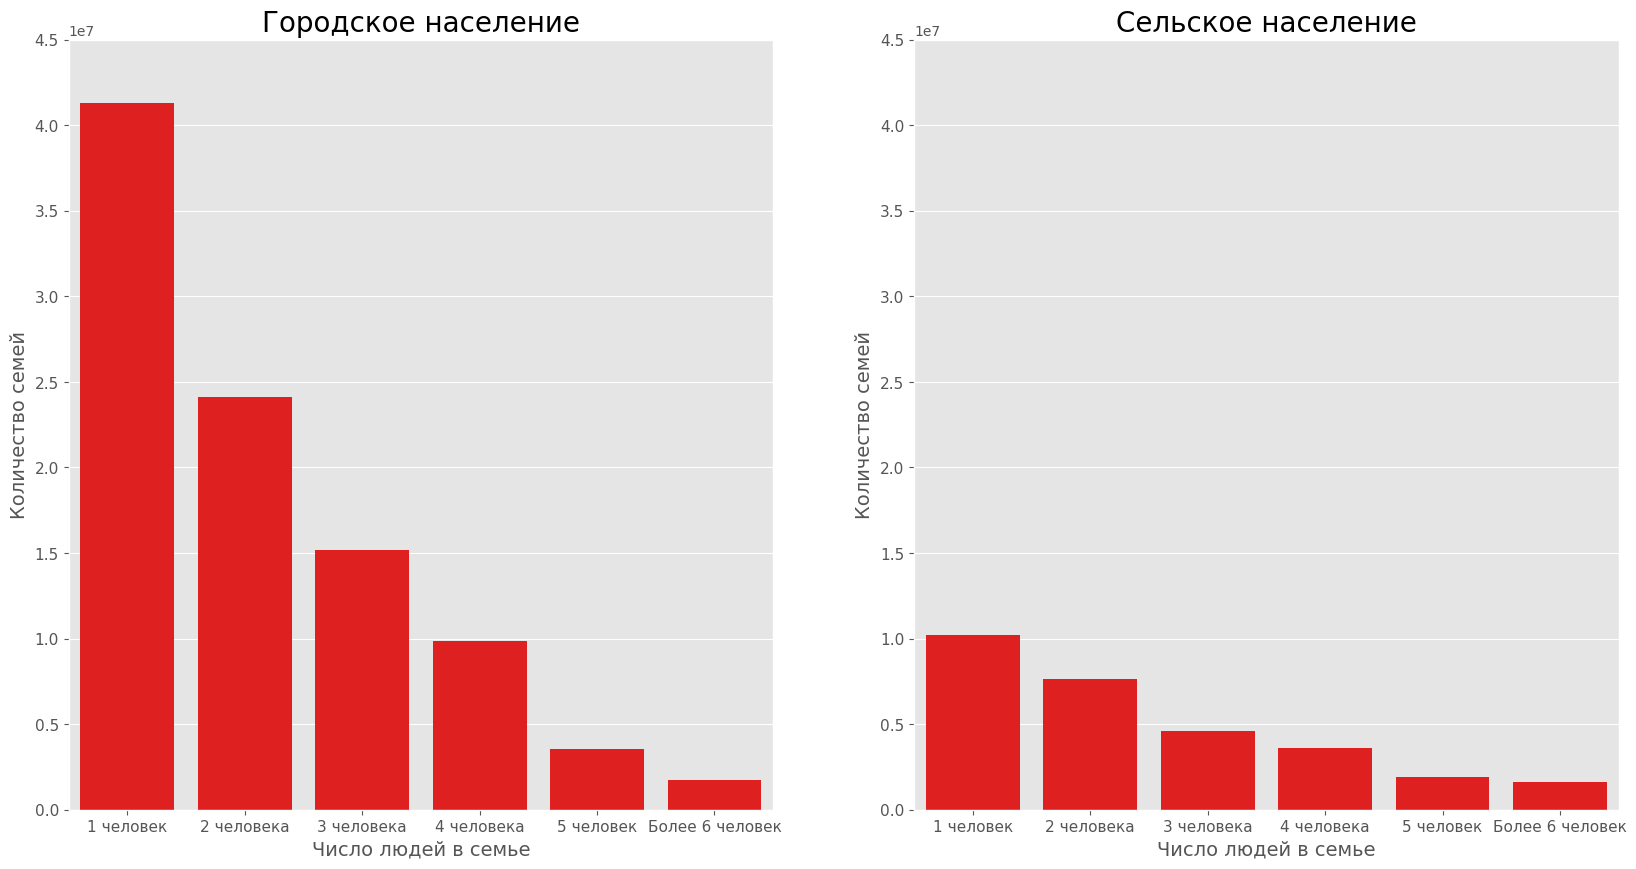

In [6]:
model.plot_households_distribution(save_path="D:/Учёба/4_курс/Диплом/текст/img/households_distibution_theory.png")

### 1.5 Посмотреть распределения внутри домохозяйств для сгенерированых данных

0

<Figure size 2000x1000 with 0 Axes>

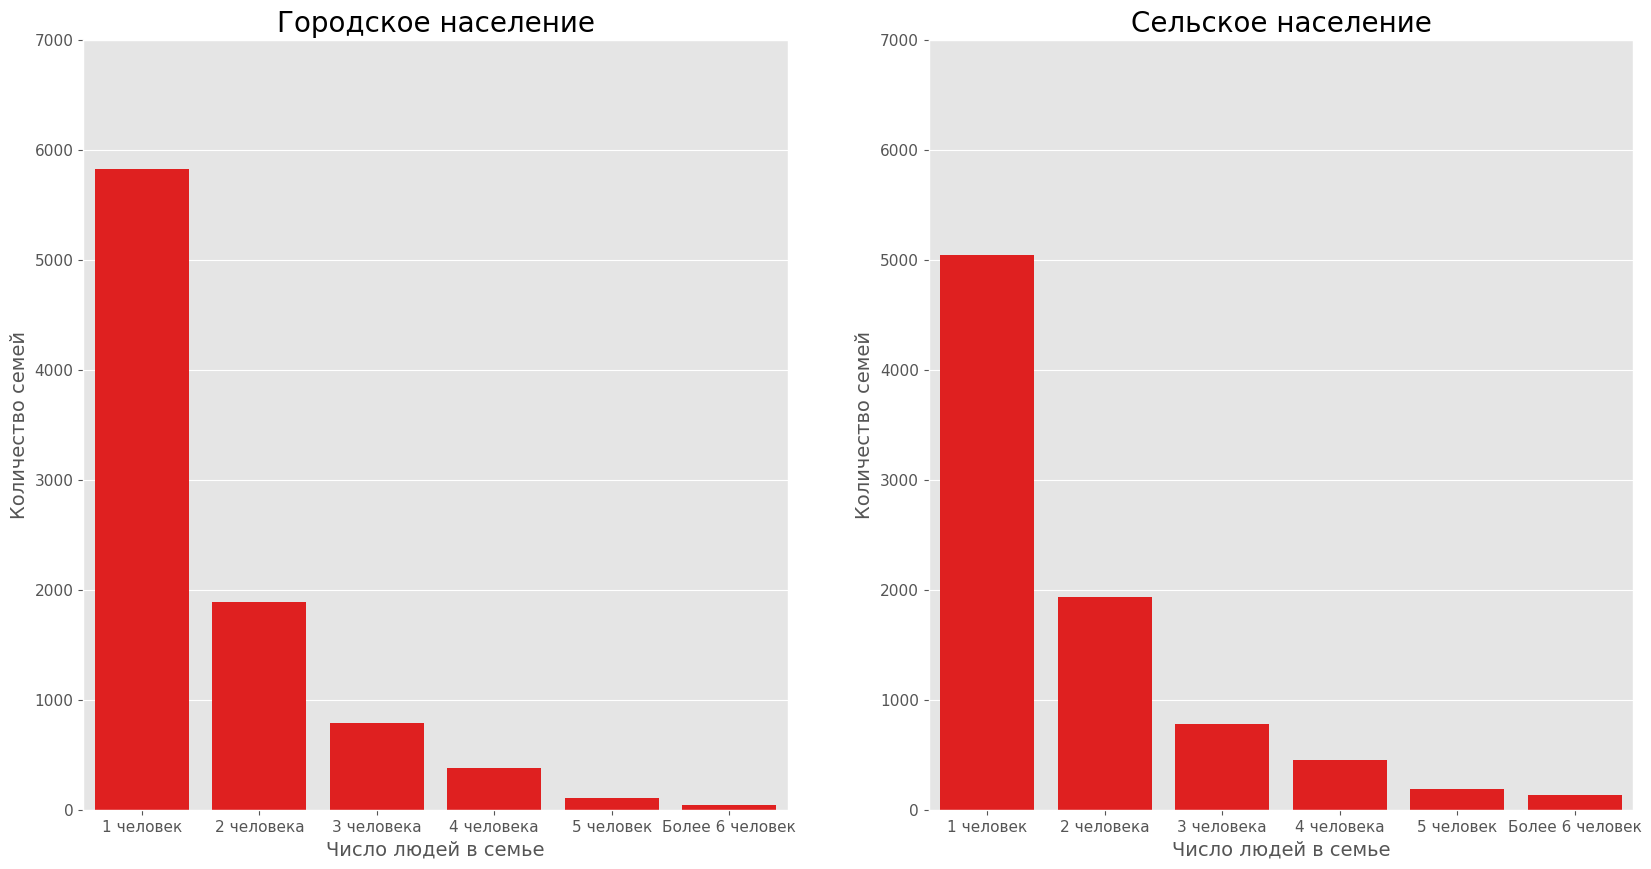

In [7]:
model.plot_households_distribution_generated_population(ylim=7000,
                                                        save_path="D:/Учёба/4_курс/Диплом/текст/img/households_distibution_generated.png")

### 1.6 Посмотреть распределения размеров предприятий

2024-04-23 21:09:31.368072 : Рисуется распределение домохозяйств по размеру ... 


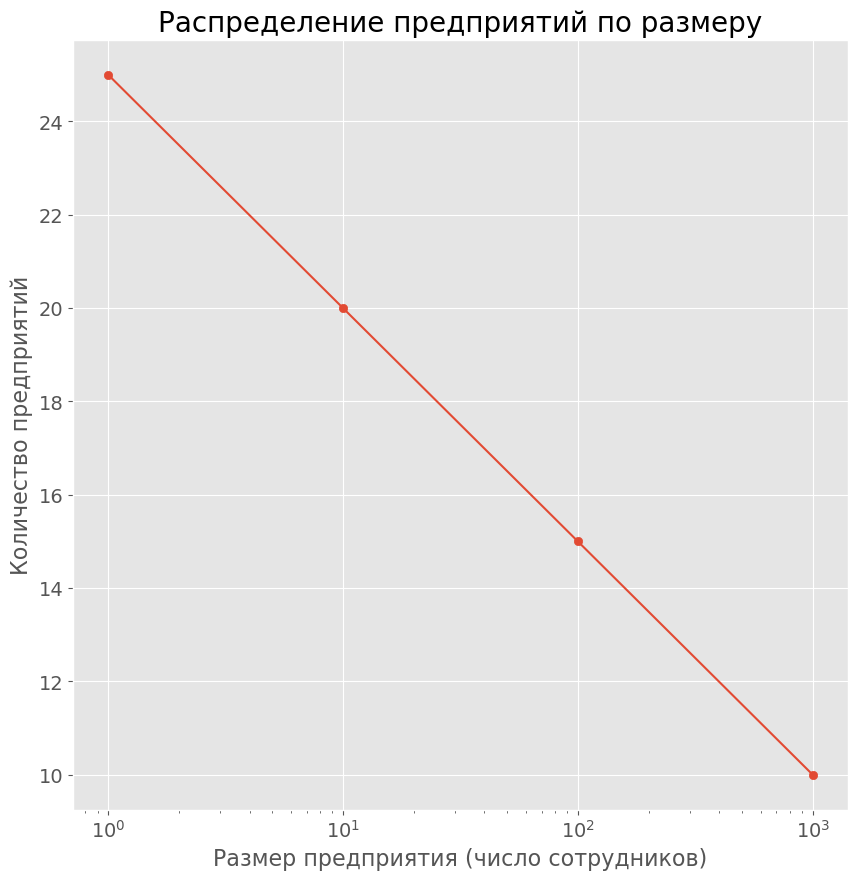

0

In [8]:
model.plot_manufactures_size_distribution(save_path="D:/Учёба/4_курс/Диплом/текст/img/manufactoris_distribution.png")

#### 1.6.1 Справка, как делал этот расчет

предприятия разного размера сдлеать (линейная зависимость от числа сотрудников) данные мне должны присласть по америке 
small world - это как распределять контакты для маленьких компаний. Так же в классе. Можно не смотреть на департаменты, надо получить гитограмму.
надо подобрать папаметр - сколько ребер надо перекинуть




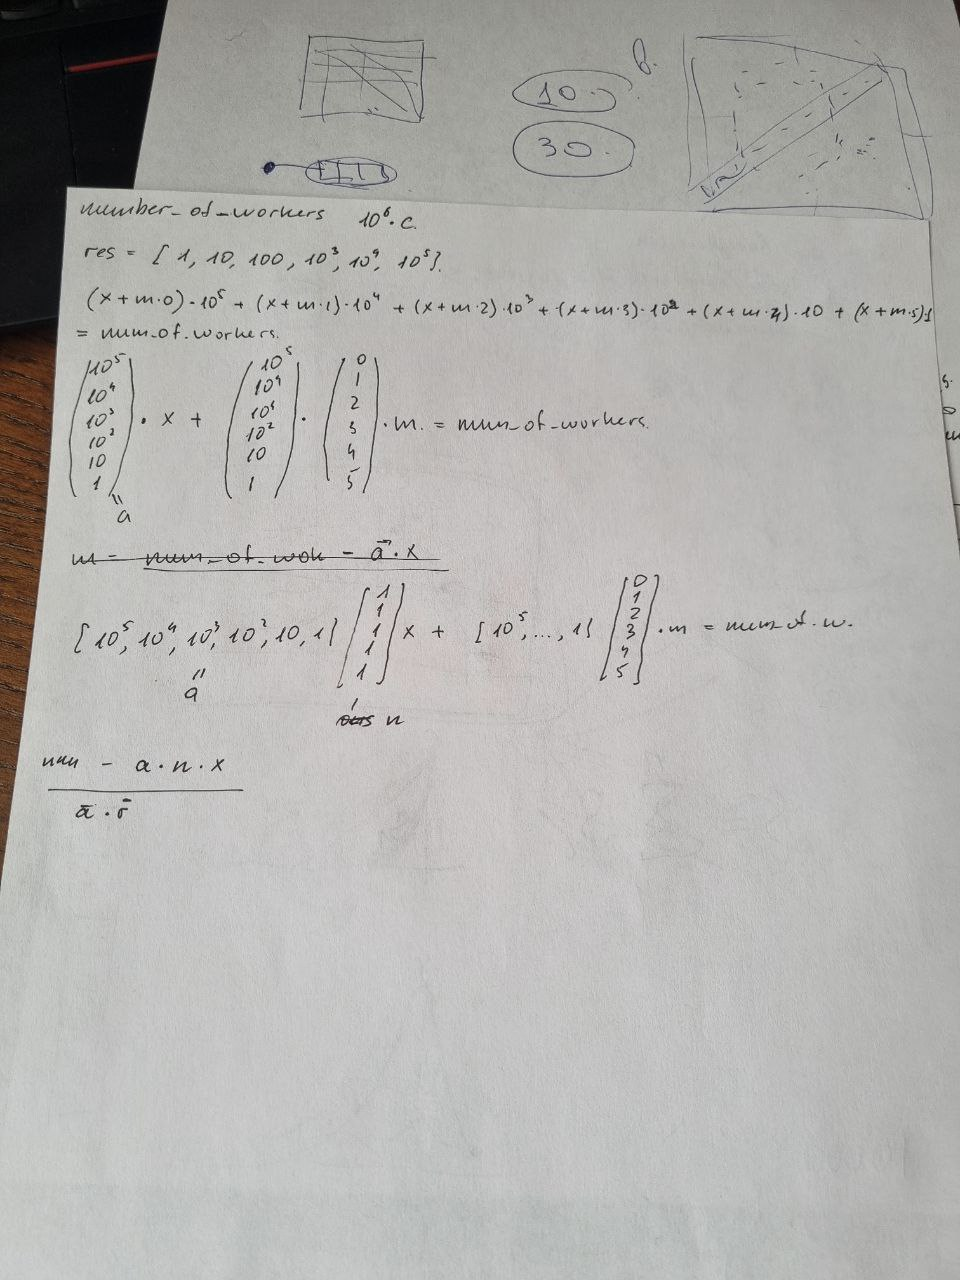


### 1.7 Посмотреть распределения степеней вершин для всей популяции

2024-04-23 21:09:34.945857 : Создается граф по матрице контактов ... 
2024-04-23 21:09:35.033373 : Вычисление степеней вершин для матрицы контактов ... 


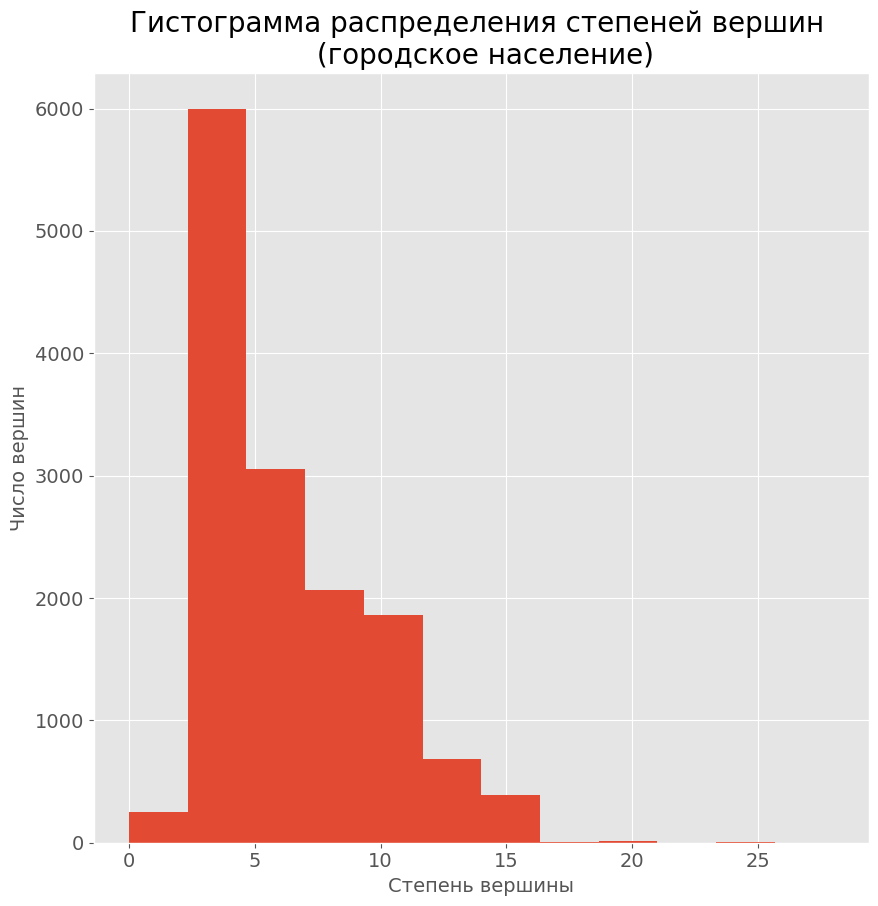

0

In [9]:
model.plot_total_connections_hist(bins=12,
                                  population_type = "urban",
                                  save_path="D:/Учёба/4_курс/Диплом/текст/img/nodes_degrees_urban.png",
                                  title="Гистограмма распределения степеней вершин \n (городское население)")

2024-04-23 21:09:38.733369 : Создается граф по матрице контактов ... 
2024-04-23 21:09:38.818041 : Вычисление степеней вершин для матрицы контактов ... 


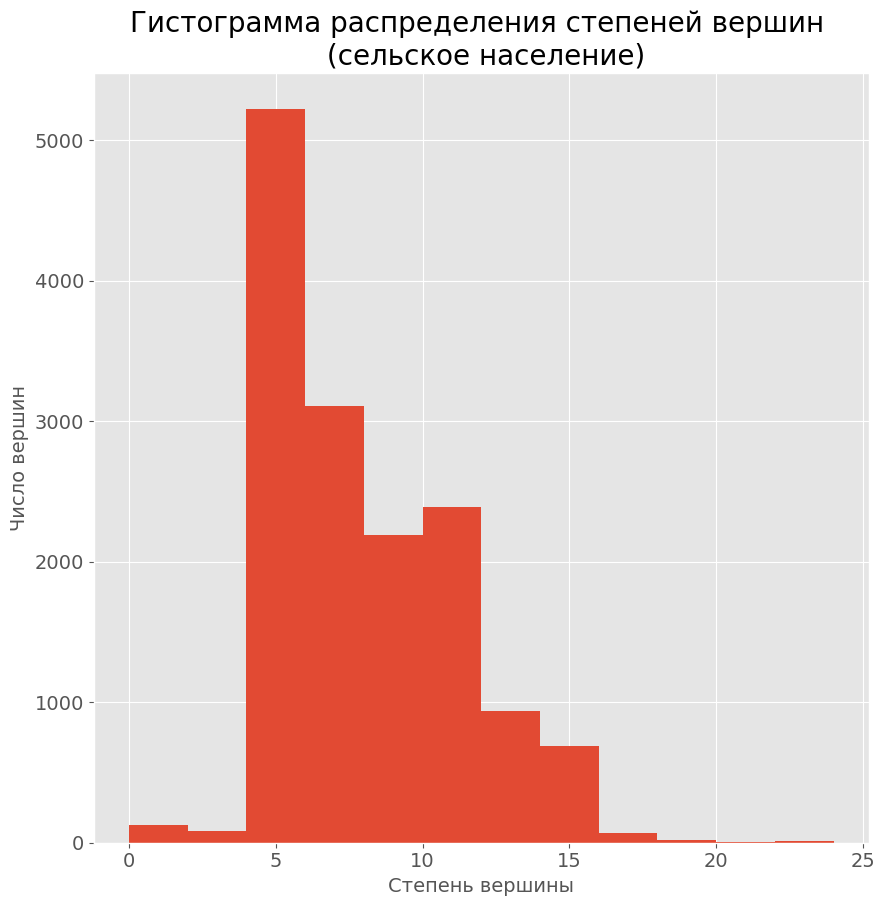

0

In [10]:
model.plot_total_connections_hist(bins=12,
                                  population_type = "rural", 
                                  save_path="D:/Учёба/4_курс/Диплом/текст/img/nodes_degrees_rural.png",
                                  title="Гистограмма распределения степеней вершин \n (сельское население)")

### 1.7.1 Можно так же посмотреть распределения степеней вершин для конкретного предприятия

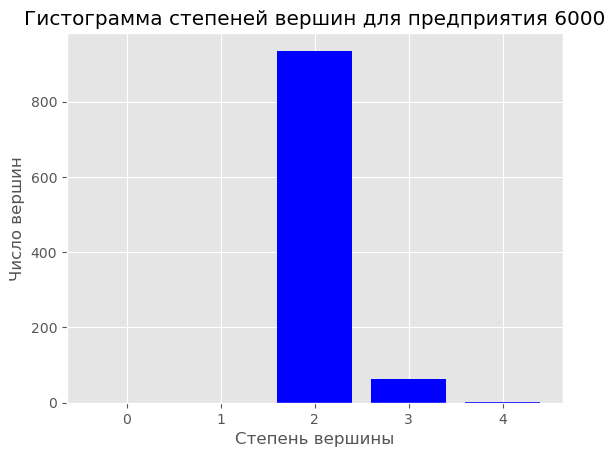

0

In [11]:
model.plot_manufactures_connections_hist()

### 1.8 Посмотреть граф контактов внутри случайного предприятия

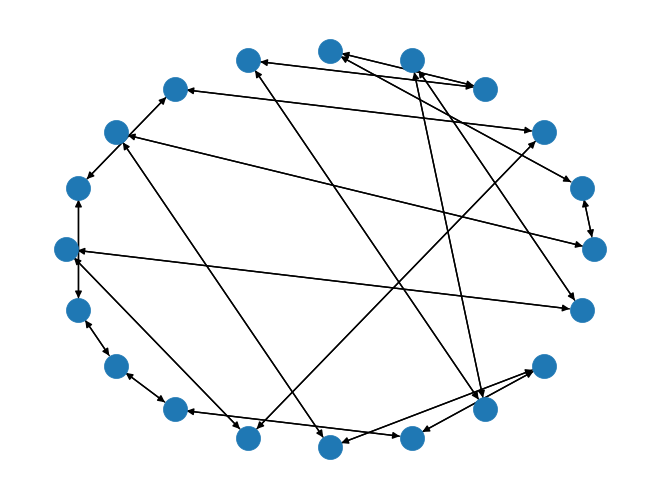

0

In [12]:
model.plot_manufactures_connections_graph(departament_id=1300, save_path="D:/Учёба/4_курс/Диплом/текст/img/graph_connections.png")

# 2 Эксперименты

## 2.1 Локдаун

In [13]:
population_size = 100000
largest_manufactures_number = 10
gamma=1/20
beta_0 = 10.0

### 2.1.1 Случай без локдауна

In [14]:
model_nonloc = gr.MyPopulation()
model_nonloc.generate_total_population(population_size = population_size, 
                                       largest_manufactures_number=largest_manufactures_number,
                                       lockdown=False)

2024-04-23 21:09:48.727108 : Строится популяция для городского населения ... 
2024-04-23 21:09:48.727108 : Запуск функции создания популяции ... 
2024-04-23 21:09:49.275395 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:09:49.328798 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:09:49.399772 : Формирование домохозяйств ... 
2024-04-23 21:09:49.592981 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:09:53.607821 : Создается контакты внутри школ ... 
2024-04-23 21:09:55.074646 : Создается контакты внутри предприятий ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:10:11.577929 : Создается контакты внутри университетов ... 


  0%|          | 0/15 [00:00<?, ?it/s]

2024-04-23 21:10:14.868487 : Создание популяции завершено ... 
2024-04-23 21:10:15.153340 : Строится популяция для сельского населения ... 
2024-04-23 21:10:15.153340 : Запуск функции создания популяции ... 
2024-04-23 21:10:15.454228 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:10:15.501117 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:10:15.570151 : Формирование домохозяйств ... 
2024-04-23 21:10:15.755115 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:10:19.600355 : Создается контакты внутри школ ... 
2024-04-23 21:10:21.224264 : Создается контакты внутри предприятий ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:10:36.814104 : Создается контакты внутри университетов ... 


  0%|          | 0/14 [00:00<?, ?it/s]

2024-04-23 21:10:39.721081 : Создание популяции завершено ... 


0

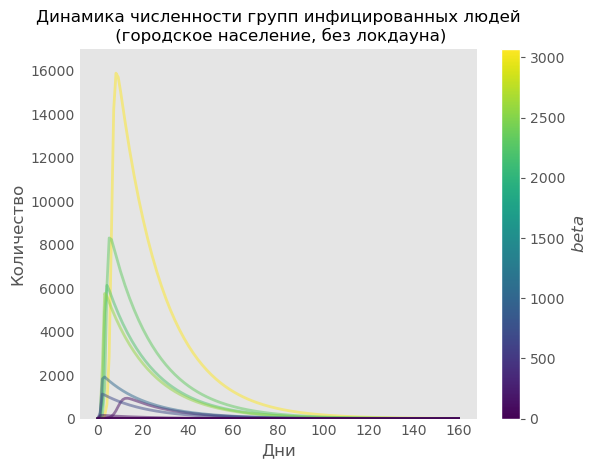

--- Основная статистика ---
Всего было заражено 40239 людей из 47897 (84.01%)
пик заражения по группам 5
Длительность  159


0

In [15]:
model_nonloc.plot_sir_model_curve(population_size = population_size, 
                                  gamma=gamma, beta_0=beta_0,
                                  plot_s = False, plot_i = True, plot_r = False,
                                  use_label = False,
                                  use_generated_population_nodes_degrees=True,
                                  population_type = "urban",
                                  save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_nonlockdown_urban_I.png", 
                                  ylim = 17000,
                                  title = "Динамика численности групп инфицированных людей\n (городское население, без локдауна)")

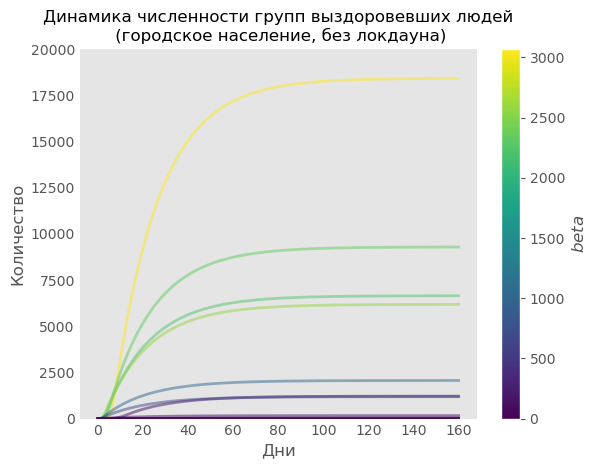

--- Основная статистика ---
Всего было заражено 40239 людей из 47897 (84.01%)
пик заражения по группам 5
Длительность  159


0

In [16]:
model_nonloc.plot_sir_model_curve(population_size = population_size, 
                                  gamma=gamma, beta_0=beta_0,
                                  plot_s=False, plot_i=False, plot_r=True,
                                  use_label=False,
                                  use_generated_population_nodes_degrees=True,
                                  population_type = "urban",
                                  save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_nonlockdown_urban_R.png", 
                                  ylim = 20000,
                                  title = "Динамика численности групп выздоровевших людей\n (городское население, без локдауна)")

### 2.1.2 Случай с локдауном

In [17]:
model_loc = gr.MyPopulation()
model_loc.generate_total_population(population_size = population_size, 
                                    largest_manufactures_number=largest_manufactures_number,
                                    lockdown=True)

2024-04-23 21:11:08.256284 : Строится популяция для городского населения ... 
2024-04-23 21:11:08.256284 : Запуск функции создания популяции ... 
2024-04-23 21:11:08.541220 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:11:08.588108 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:11:08.657079 : Формирование домохозяйств ... 
2024-04-23 21:11:08.826436 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:11:13.519161 : Связи внутри школ не создаются, как так введен локдаун ... 
2024-04-23 21:11:13.519161 : Контакты внутри предприятий создаются только для 30% популяции ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:11:14.891546 : Связи внутри университетов не создаются, как так введен локдаун ... 
2024-04-23 21:11:15.138809 : Создание популяции завершено ... 
2024-04-23 21:11:15.408054 : Строится популяция для сельского населения ... 
2024-04-23 21:11:15.408054 : Запуск функции создания популяции ... 
2024-04-23 21:11:15.692997 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:11:15.739886 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:11:15.808922 : Формирование домохозяйств ... 
2024-04-23 21:11:15.978126 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:11:20.167897 : Создается контакты внутри школ ... 
2024-04-23 21:11:21.755631 : Создается контакты внутри предприятий ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:11:23.114212 : Создается контакты внутри университетов ... 


  0%|          | 0/14 [00:00<?, ?it/s]

2024-04-23 21:11:26.106213 : Создание популяции завершено ... 


0

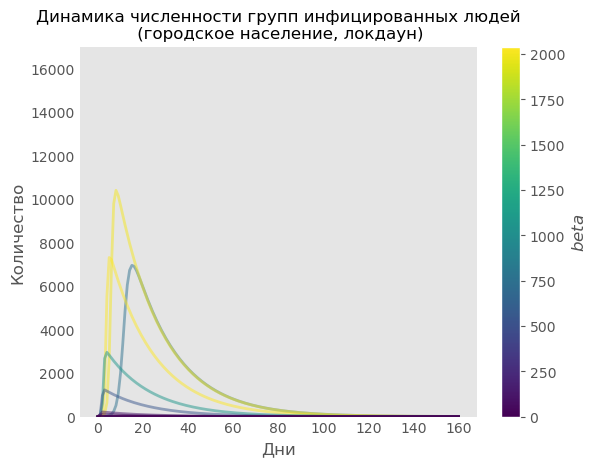

--- Основная статистика ---
Всего было заражено 29193 людей из 47897 (60.95%)
пик заражения по группам 6
Длительность  159


0

In [18]:
model_loc.plot_sir_model_curve(population_size = population_size, 
                               gamma=gamma, beta_0=beta_0,
                               plot_s=False, plot_i=True, plot_r=False,
                               use_label=False,
                               use_generated_population_nodes_degrees=True,
                               population_type = "urban",
                               save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_lockdown_urban_I.png", 
                               ylim = 17000,
                               title = "Динамика численности групп инфицированных людей\n (городское население, локдаун)")

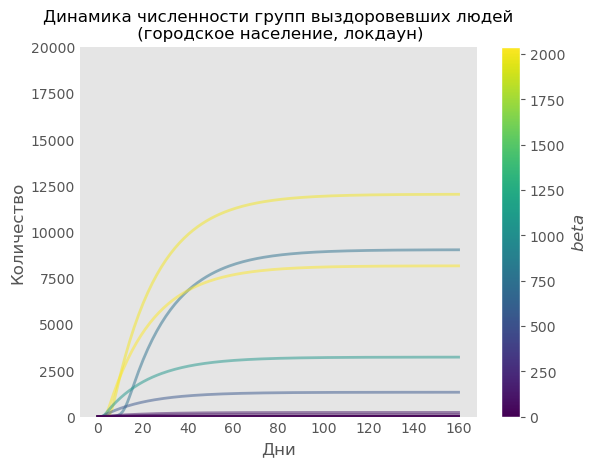

--- Основная статистика ---
Всего было заражено 29193 людей из 47897 (60.95%)
пик заражения по группам 6
Длительность  159


0

In [19]:
model_loc.plot_sir_model_curve(population_size = population_size, 
                               gamma=gamma, beta_0=beta_0,
                               plot_s=False, plot_i=False, plot_r=True,
                               use_label=False,
                               use_generated_population_nodes_degrees=True,
                               population_type = "urban",
                               save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_lockdown_urban_R.png", 
                               ylim = 20000,
                               title = "Динамика численности групп выздоровевших людей\n (городское население, локдаун)")

## 2.2. Сравнение городского и сельского населений

In [20]:
population_size = 100000
largest_manufactures_number = 10
gamma=1/10
beta_0=5.0

In [21]:
model_compare = gr.MyPopulation()
model_compare.generate_total_population(population_size = population_size, 
                                        largest_manufactures_number=largest_manufactures_number,
                                        lockdown=False)

2024-04-23 21:11:51.219185 : Строится популяция для городского населения ... 
2024-04-23 21:11:51.219185 : Запуск функции создания популяции ... 
2024-04-23 21:11:51.551339 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:11:51.589114 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:11:51.651638 : Формирование домохозяйств ... 
2024-04-23 21:11:51.804986 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:11:55.736955 : Создается контакты внутри школ ... 
2024-04-23 21:11:56.955959 : Создается контакты внутри предприятий ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:12:13.867830 : Создается контакты внутри университетов ... 


  0%|          | 0/15 [00:00<?, ?it/s]

2024-04-23 21:12:17.261425 : Создание популяции завершено ... 
2024-04-23 21:12:17.380689 : Строится популяция для сельского населения ... 
2024-04-23 21:12:17.380689 : Запуск функции создания популяции ... 
2024-04-23 21:12:17.889758 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:12:17.936681 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:12:17.990189 : Формирование домохозяйств ... 
2024-04-23 21:12:18.190538 : Создание матрицы контактов внутри домохозяйств ... 
2024-04-23 21:12:22.416858 : Создается контакты внутри школ ... 
2024-04-23 21:12:24.360039 : Создается контакты внутри предприятий ... 


  0%|          | 0/4 [00:00<?, ?it/s]

2024-04-23 21:12:41.013713 : Создается контакты внутри университетов ... 


  0%|          | 0/14 [00:00<?, ?it/s]

2024-04-23 21:12:43.983074 : Создание популяции завершено ... 


0

 ### 2.2.1 Городское население

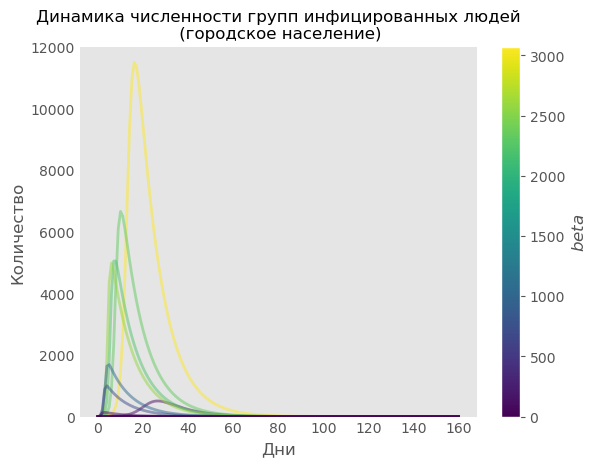

--- Основная статистика ---
Всего было заражено 31556 людей из 47897 (65.88%)
пик заражения по группам 10
Длительность  112


0

In [22]:
model_compare.plot_sir_model_curve(population_size = population_size, 
                                   gamma=gamma, beta_0=beta_0,
                                   plot_s=False, plot_i=True, plot_r=False,
                                   use_label=False,
                                   use_generated_population_nodes_degrees=True,
                                   population_type = "urban",
                                   title = "Динамика численности групп инфицированных людей\n (городское население)",
                                   ylim = 12000,
                                   save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_example_I_urban.png")

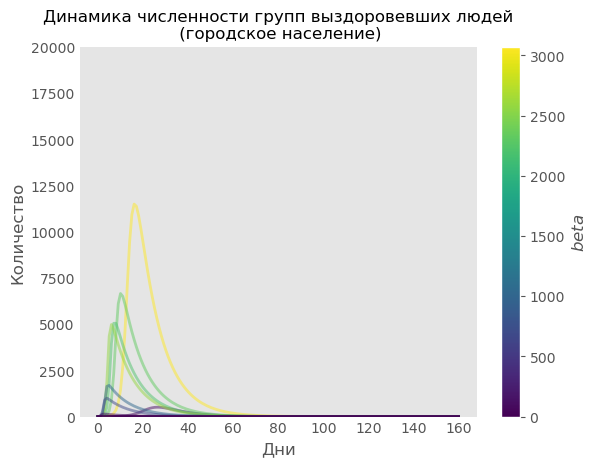

--- Основная статистика ---
Всего было заражено 31556 людей из 47897 (65.88%)
пик заражения по группам 10
Длительность  112


0

In [23]:
model_compare.plot_sir_model_curve(population_size = population_size, 
                                   gamma=gamma, beta_0=beta_0,
                                   plot_s=False, plot_i=True, plot_r=False,
                                   use_label=False,
                                   use_generated_population_nodes_degrees=True,
                                   population_type = "urban",
                                   title = "Динамика численности групп выздоровевших людей\n (городское население)",
                                   ylim = 20000,
                                   save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_example_R_urban.png")

 ### 2.2.2 Сельское население

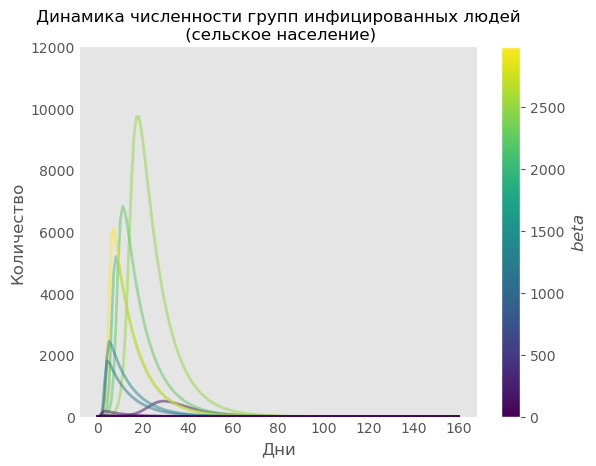

--- Основная статистика ---
Всего было заражено 32874 людей из 49614 (66.26%)
пик заражения по группам 11
Длительность  112


0

In [24]:
model_compare.plot_sir_model_curve(population_size = population_size, 
                                   gamma=gamma, beta_0=beta_0,
                                   plot_s=False, plot_i=True, plot_r=False,
                                   use_label=False,
                                   use_generated_population_nodes_degrees=True,
                                   population_type = "rural", 
                                   title = "Динамика численности групп инфицированных людей\n (сельское население)",
                                   ylim = 12000,
                                   save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_example_I_rural.png")

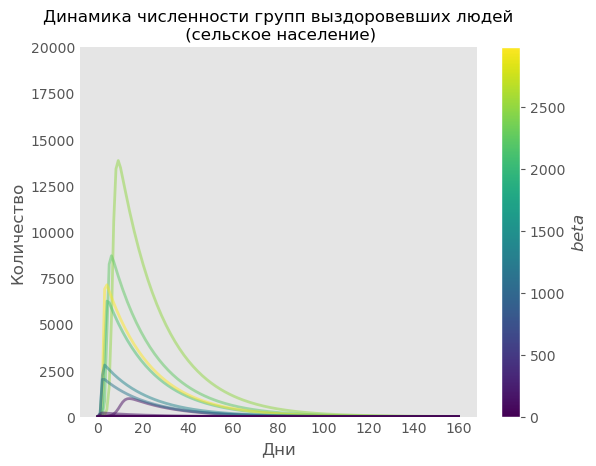

--- Основная статистика ---
Всего было заражено 41982 людей из 49614 (84.62%)
пик заражения по группам 5
Длительность  159


0

In [31]:
model_compare.plot_sir_model_curve(population_size = population_size, 
                                   gamma=gamma, beta_0=beta_0,
                                   plot_s=False, plot_i=True, plot_r=False,
                                   use_label=False,
                                   use_generated_population_nodes_degrees=True,
                                   population_type = "rural", 
                                   title = "Динамика численности групп выздоровевших людей\n (сельское население)",
                                   ylim = 20000,
                                   save_path="D:/Учёба/4_курс/Диплом/текст/img/sir_model_example_R_rural.png")

## 2.3 Ипользование подхода "small-world" для создания связей

In [25]:
population_size = 100000
largest_manufactures_number = 10
gamma=1/20
beta_0 = 10.0

In [26]:
model_small_world = gr.MyPopulation()
model_small_world.generate_total_population(population_size=population_size, 
                                            largest_manufactures_number=largest_manufactures_number,
                                            lockdown=False,
                                            use_small_world_approach=True,
                                            betta = 0.5)

2024-04-23 21:13:22.735582 : Строится популяция для городского населения ... 
2024-04-23 21:13:22.735582 : Запуск функции создания популяции ... 
2024-04-23 21:13:23.036239 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:13:23.083128 : Создается популяция женщин на основе шаблона ... 
2024-04-23 21:13:42.143759 : Строится популяция для сельского населения ... 
2024-04-23 21:13:42.143759 : Запуск функции создания популяции ... 
2024-04-23 21:13:42.475669 : Создается популяция мужчин на основе шаблона ... 
2024-04-23 21:13:42.513443 : Создается популяция женщин на основе шаблона ... 


0

2024-04-23 21:14:04.513785 : Создается граф по матрице контактов ... 
2024-04-23 21:14:04.798998 : Вычисление степеней вершин для матрицы контактов ... 


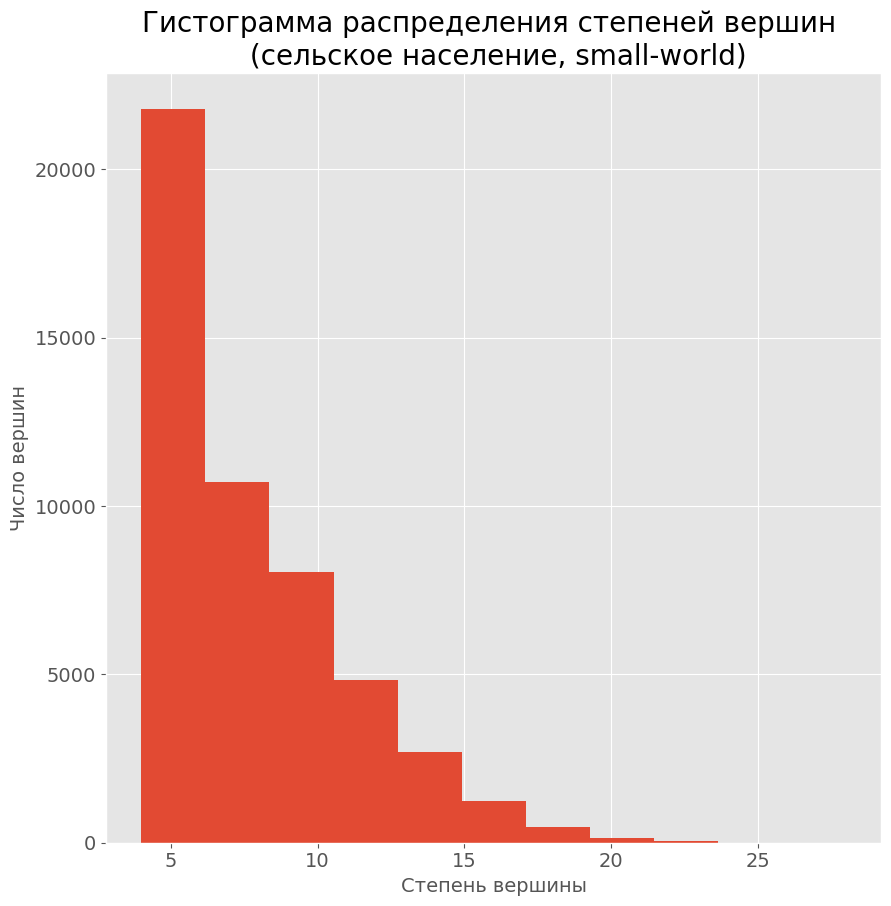

0

In [27]:
model_small_world.plot_total_connections_hist(bins=11, population_type = "rural",
                                              title="Гистограмма распределения степеней вершин \n (сельское население, small-world)")

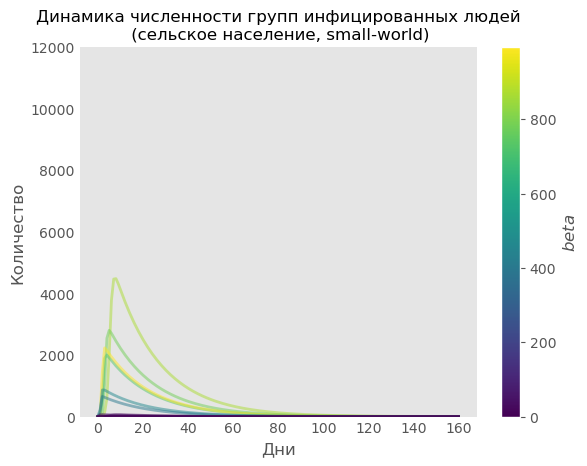

--- Основная статистика ---
Всего было заражено 13193 людей из 14839 (88.91%)
пик заражения по группам 5
Длительность  159


0

In [28]:
model.plot_sir_model_curve(population_size = population_size, 
                           gamma=gamma, beta_0=beta_0,
                           plot_s=False, plot_i=True, plot_r=False,
                           use_label=False,
                           use_generated_population_nodes_degrees=True,
                           population_type = "rural", 
                           title = "Динамика численности групп инфицированных людей\n (сельское население, small-world)",
                           ylim = 12000)

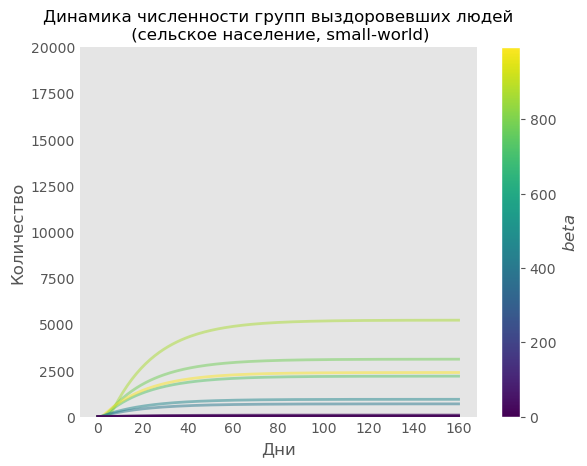

--- Основная статистика ---
Всего было заражено 13193 людей из 14839 (88.91%)
пик заражения по группам 5
Длительность  159


0

In [29]:
model.plot_sir_model_curve(population_size = population_size, 
                           gamma=gamma, beta_0=beta_0,
                           plot_s=False, plot_i=False, plot_r=True,
                           use_label=False,
                           use_generated_population_nodes_degrees=True,
                           population_type = "rural",  
                           title = "Динамика численности групп выздоровевших людей\n (сельское население, small-world)",
                           ylim = 20000)

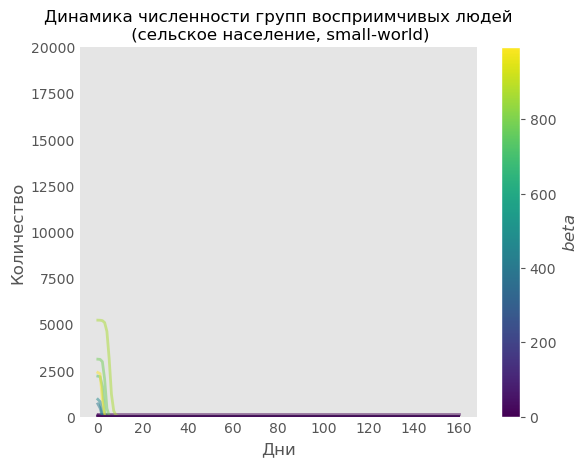

--- Основная статистика ---
Всего было заражено 13193 людей из 14839 (88.91%)
пик заражения по группам 5
Длительность  159


0

In [30]:
model.plot_sir_model_curve(population_size = population_size, 
                           gamma=gamma, beta_0=beta_0,
                           plot_s=True, plot_i=False, plot_r=False,
                           use_label=False,
                           use_generated_population_nodes_degrees=True,
                           population_type = "rural",  
                           title = "Динамика численности групп восприимчивых людей\n (сельское население, small-world)",
                           ylim = 20000)

---

In [ ]:
# Сохраняем датафрейм в формате pickle
import pickle

with open('population.pkl', 'wb') as f:
    pickle.dump(model.population_total, f)

with open('matrix_r.pkl', 'wb') as f:
    pickle.dump(model.connections_matrix_rural, f)

with open('matrix_u.pkl', 'wb') as f:
    pickle.dump(model.connections_matrix_urban, f)

with open('population.pkl', 'rb') as f:
    population_total = pickle.load(f)

with open('matrix_r.pkl', 'rb') as f:
    connections_matrix_rural = pickle.load(f)

with open('matrix_u.pkl', 'rb') as f:
    connections_matrix_urban = pickle.load(f)